Streaming output truncated to the last 5000 lines.
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0945-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0946-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0947-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0948-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0949-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0950-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0951-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0952-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0954-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0955-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0956-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0957-0001.jpeg  
  inflating: chest_xray_data/train/NORMAL/NORMAL2-IM-0959-0001.jpeg  
  inflating: chest_xray_data/train/NORM

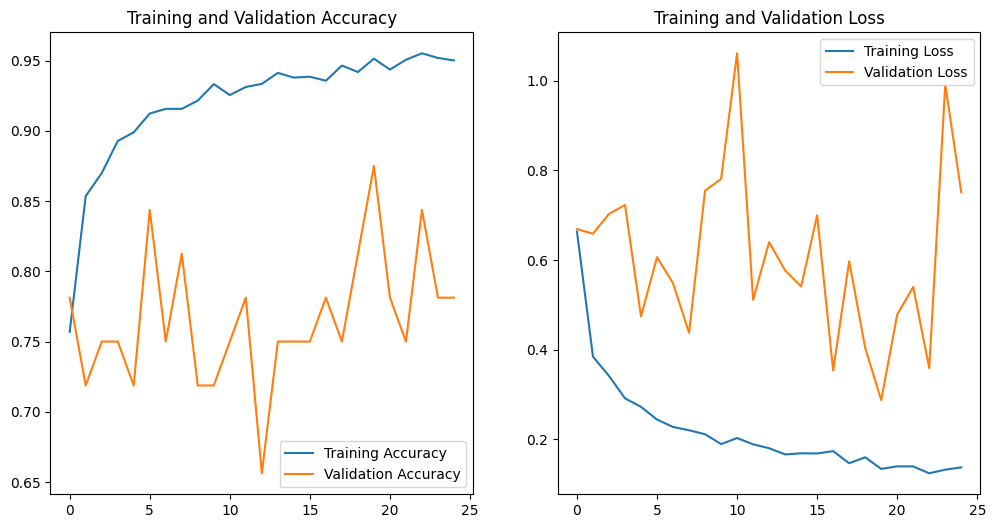

24/24 [==============================] - 7s 260ms/step - loss: 0.4567 - accuracy: 0.8815
Test Accuracy: 0.8815104365348816
25/25 [==============================] - 8s 255ms/step
Confusion Matrix
[[ 98   0   3   5]
 [  4 154  74   2]
 [  0   3 387   0]
 [  0   0   0  41]]
Classification Report
              precision    recall  f1-score   support

    COVID-19       0.96      0.92      0.94       106
Tuberculosis       0.98      0.66      0.79       234
   Pneumonia       0.83      0.99      0.91       390
      Normal       0.85      1.00      0.92        41

    accuracy                           0.88       771
   macro avg       0.91      0.89      0.89       771
weighted avg       0.90      0.88      0.88       771



/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
# Install necessary libraries
!pip install kaggle
!pip install tensorflow
!pip install matplotlib
!pip install seaborn

# Upload Kaggle API key
from google.colab import files
files.upload()  # This will prompt you to upload the kaggle.json file

# Setup Kaggle API credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d jtiptj/chest-xray-pneumoniacovid19tuberculosis
!unzip chest-xray-pneumoniacovid19tuberculosis.zip -d chest_xray_data

# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Define dataset directories
base_dir = 'chest_xray_data/'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Define image size and batch size
image_size = (150, 150)
batch_size = 32

# Data augmentation and rescaling
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Data generators
train_generator = train_datagen.flow_from_directory(train_dir, target_size=image_size, batch_size=batch_size, class_mode='categorical')
val_generator = val_test_datagen.flow_from_directory(val_dir, target_size=image_size, batch_size=batch_size, class_mode='categorical')
test_generator = val_test_datagen.flow_from_directory(test_dir, target_size=image_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes: COVID-19, Tuberculosis, Pneumonia, Normal
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()

# Train the model
epochs = 25

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=epochs
)

# Plot training and validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f'Test Accuracy: {test_acc}')

# Generate confusion matrix and classification report
Y_pred = model.predict(test_generator, steps=test_generator.samples // batch_size + 1)
y_pred = np.argmax(Y_pred, axis=1)

print('Confusion Matrix')
print(confusion_matrix(test_generator.classes, y_pred))

print('Classification Report')
target_names = ['COVID-19', 'Tuberculosis', 'Pneumonia', 'Normal']
print(classification_report(test_generator.classes, y_pred, target_names=target_names))

# Save the model
model.save('chest_xray_classification_model.h5')


In [ ]:
model.save('my_model.keras')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import files

# Path to the file you want to download
file_path = '/content/chest-xray-pneumoniacovid19tuberculosis.zip'

# Download the file
files.download(file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing import image

# Assuming you have trained and evaluated Model 2, and obtained the necessary outputs

# Define class names
class_names = ['COVID-19', 'Tuberculosis', 'Pneumonia', 'Normal']

# Load and preprocess the test image
test_image_path = '/content/chest_xray_data/test/COVID19/COVID19(460).jpg'  # Replace with the actual path to your image

img = image.load_img(test_image_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
test_image = np.expand_dims(img_array, axis=0)

# Make predictions on the test image
test_predictions = model.predict(test_image)
test_predicted_label = np.argmax(test_predictions, axis=1)[0]
test_predicted_class_name = class_names[test_predicted_label]

# Convert the true label to class name
test_true_label = 0  # Replace with the true label of the test image
test_true_class_name = class_names[test_true_label]

# Print the predicted and true labels
print('Predicted label:', test_predicted_class_name)
print('True label:', test_true_class_name)

# Show the test image
plt.imshow(img)
plt.title(f'Predicted: {test_predicted_class_name}\nTrue: {test_true_class_name}')
plt.axis('off')
plt.show()

NameError: name 'model' is not defined

1/1 [==============================] - 0s 28ms/step
Predicted class: COVID-19
True class: COVID-19


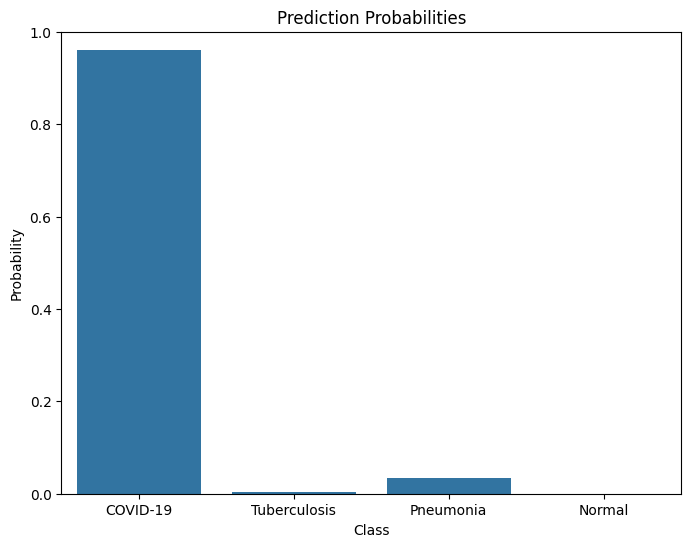

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image

class_names = ['COVID-19', 'Tuberculosis', 'Pneumonia', 'Normal']

# Load and preprocess the test image
test_image_path = '/content/chest_xray_data/test/COVID19/COVID19(460).jpg'  # Replace with the actual path to your image

img = image.load_img(test_image_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
test_image = np.expand_dims(img_array, axis=0)

# Make predictions on the test image
test_predictions = model.predict(test_image)
test_predicted_label = np.argmax(test_predictions, axis=1)[0]
test_predicted_class_name = class_names[test_predicted_label]

# Convert the true label to class name
test_true_label = 0  # Replace with the true label of the test image
test_true_class_name = class_names[test_true_label]

# Print prediction result
print("Predicted class:", test_predicted_class_name)
print("True class:", test_true_class_name)

# Plot bar chart for prediction probabilities
plt.figure(figsize=(8, 6))
sns.barplot(x=class_names, y=test_predictions[0])
plt.xlabel('Class')
plt.ylabel('Probability')
plt.title('Prediction Probabilities')
plt.ylim([0, 1])
plt.show()